In [15]:
# === ここは既存の profile_once(...) でベースライン推定済み想定 ===
# base = profile_once(L_list, p, A, dA, verbose=True)
# print("zeta* =", base['zeta'], " pc* =", base['pc'], " nu* =", base['nu'])

# ===== FAST Jackknife over p: zeta を固定して (pc,nu) だけ最小化 =====
def min_pc_nu_given_zeta(Ls, p, A, dA, zeta,
                         rho_coarse_steps=31, nu_coarse_steps=31,
                         rho_half_ref=0.010, nu_half_ref=0.300, rho_ref_steps=31, nu_ref_steps=31):
    # coarse grids
    rho_grid_c = np.linspace(p.min(), p.max(), rho_coarse_steps)
    nu_grid_c  = np.linspace(nu_range[0], nu_range[1], nu_coarse_steps)

    best = (np.inf, None, None)  # S, rho, nu
    for rho0 in rho_grid_c:
        for nu0 in nu_grid_c:
            S, _ = eval_quality(Ls, p, A, dA, rho0, nu0, zeta)
            if S < best[0]:
                best = (S, rho0, nu0)
    _, rho_c, nu_c = best

    # local refine
    rho_grid_r = linspace_clip(rho_c, rho_half_ref, rho_ref_steps, p.min(), p.max())
    nu_grid_r  = linspace_clip(nu_c,  nu_half_ref,  nu_ref_steps,  *nu_range)

    best_r = (np.inf, None, None)
    for rho0 in rho_grid_r:
        for nu0 in nu_grid_r:
            S, _ = eval_quality(Ls, p, A, dA, rho0, nu0, zeta)
            if S < best_r[0]:
                best_r = (S, rho0, nu0)
    S_star, rho_star, nu_star = best_r
    return dict(pc=rho_star, nu=nu_star, S=S_star)

# ---- 実行：p-LOO（zeta は固定）----
z_fix = float(base['zeta'])
pcs, nus = [], []
N = p.size
print("\n[fast p-LOO jackknife] zeta fixed =", z_fix)
for j in range(N):
    mask_j = np.ones(N, dtype=bool); mask_j[j] = False
    pj, Aj, dAj = p[mask_j], A[:, mask_j], dA[:, mask_j]
    est = min_pc_nu_given_zeta(L_list, pj, Aj, dAj, z_fix)
    pcs.append(est['pc']); nus.append(est['nu'])

def jackknife_se(vals):
    v = np.asarray(vals, float); n = v.size
    m = v.mean(); se = np.sqrt((n-1)/n * np.sum((v - m)**2))
    return m, se

pc_mean, pc_se = jackknife_se(pcs)
nu_mean, nu_se = jackknife_se(nus)

# zeta の不確かさは、ベースラインの S(zeta) 近傍をパラボラ近似して幅を推定（手早い近似）
# 追加の厳密 LOO が必要なら従来法を使う
def zeta_se_by_parabola(Ls, p, A, dA, z_star, dz=0.15, steps=9):
    zs = np.linspace(z_star - dz, z_star + dz, steps)
    Ss = []
    # 各 z で (pc,nu) を簡易最小化（coarseのみでもOK）
    for z0 in zs:
        rho_grid_c = np.linspace(p.min(), p.max(), 21)
        nu_grid_c  = np.linspace(nu_range[0], nu_range[1], 21)
        Smin = np.inf
        for rho0 in rho_grid_c:
            for nu0 in nu_grid_c:
                S, _ = eval_quality(Ls, p, A, dA, rho0, nu0, z0)
                if S < Smin: Smin = S
        Ss.append(Smin)
    zs = np.asarray(zs); Ss = np.asarray(Ss)
    # 二次近似 S ≈ a (z - z*)^2 + c → 1σ の幅を目安として sqrt(ΔS/a)
    # ΔS の決め方は厳密ではないが、実務的には ΔS ~ 0.01〜0.05 程度で感度をみる
    coef = np.polyfit(zs - z_star, Ss, 2)  # a, b, c （z*中心だと b≈0）
    a = coef[0]
    if a <= 0: return 0.0  # 曲率が負なら推定不能
    dS = 0.02
    return np.sqrt(dS / a)

zeta_se = zeta_se_by_parabola(L_list, p, A, dA, z_fix, dz=0.2, steps= 9)

print("\n=== FAST JACKKNIFE (zeta fixed) ===")
print(f"pc   = {pc_mean:.6f}  ± {pc_se:.6f}")
print(f"nu   = {nu_mean:.6f}  ± {nu_se:.6f}")
print(f"zeta = {z_fix:.6f}    ± {zeta_se:.6f}  (parabola approx)")



[fast p-LOO jackknife] zeta fixed = 2.621666666666667

=== FAST JACKKNIFE (zeta fixed) ===
pc   = 0.850750  ± 0.016599
nu   = 1.755417  ± 0.562044
zeta = 2.621667    ± 0.000000  (parabola approx)


In [2]:
# -*- coding: utf-8 -*-
"""
Variance-only FSSA with zeta profiling + Jackknife errors (simple):
- Fix p-window to [0.75, 0.90]
- Profile zeta: for each zeta, minimize S over (pc, nu) on a grid
- Report baseline (pc*, nu*, zeta*, S*)
- p-LOO Jackknife: leave one p-point out, re-profile, aggregate SEs
  (Optionally L-LOO Jackknife as well)
"""

import numpy as np
import fssa
import warnings
from itertools import product

# ---------------- Settings ----------------
npz_path = "Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz"
TEE_keys = ['TEE2','TEE3','TEE4','TEE5','TEE6']
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]

# 固定 p 窓（あなたの「効く」範囲）
#pmin, pmax = 0.75, 0.90
pmin, pmax = 0.80, 0.90

# 検索レンジ
nu_range   = (1.0, 3.0)
zeta_range = (0.5, 4.0)  # ζ>=0.5 で安定

# グリッド解像度（程よく軽い）
rho_steps_coarse  = 31
nu_steps_coarse   = 31
zeta_steps_coarse = 25

rho_half_ref  = 0.010; rho_steps_ref = 31
nu_half_ref   = 0.300; nu_steps_ref  = 31
zeta_half_ref = 0.400; zeta_steps_ref= 31

# ジャックナイフ
DO_P_JK = True
DO_L_JK = False  # 必要なら True

# 数値的安定化
GAMMA_ERR = 0.5         # npz中の *_err に掛ける係数（あなたの設定）
ERR_FLOOR = 1e-6        # 絶対床（ゼロ重み防止）

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ---------------- Utils ----------------
def eval_quality(Ls, p, A, dA, rho, nu, zeta):
    try:
        xs, ys, dys = fssa.scaledata(Ls, p, A, dA, rho, nu, zeta)
        if not (np.isfinite(xs).all() and np.isfinite(ys).all() and np.isfinite(dys).all()):
            return np.inf, None
        S = fssa.quality(xs, ys, dys)
        return (np.inf if not np.isfinite(S) else S), (xs, ys, dys)
    except Exception:
        return np.inf, None

def grid_min_fixed_zeta(Ls, p, A, dA, zeta, rho_grid, nu_grid):
    best = (np.inf, None, None, None)  # S, rho, nu, (xs,ys,dys)
    for rho0 in rho_grid:
        for nu0 in nu_grid:
            S, pack = eval_quality(Ls, p, A, dA, rho0, nu0, zeta)
            if S < best[0]:
                best = (S, rho0, nu0, pack)
    return best

def linspace_clip(center, half, steps, lo, hi):
    a = max(lo, center-half); b = min(hi, center+half)
    if a == b:
        eps = max(half, 1e-3); a = max(lo, center-eps); b = min(hi, center+eps)
    return np.linspace(a, b, steps)

def profile_once(Ls, p, A, dA):
    """zeta を走査し (pc,nu) を最良化 → 局所リファイン → 最良解を返す"""
    rho_grid_c = np.linspace(p.min(), p.max(), rho_steps_coarse)
    nu_grid_c  = np.linspace(*nu_range,  num=nu_steps_coarse)
    z_grid_c   = np.linspace(*zeta_range, num=zeta_steps_coarse)

    best = (np.inf, None, None, None, None)  # S, rho, nu, zeta, pack
    for j, z0 in enumerate(z_grid_c, 1):
        if j % max(1, len(z_grid_c)//5) == 0 or j in (1, len(z_grid_c)):
            print(f"  [coarse] zeta {j}/{len(z_grid_c)} z0={z0:.3f}")
        Smin, rho_b, nu_b, pack = grid_min_fixed_zeta(Ls, p, A, dA, z0, rho_grid_c, nu_grid_c)
        if Smin < best[0]:
            best = (Smin, rho_b, nu_b, z0, pack)

    S_c, rho_c, nu_c, zeta_c, _ = best
    # refine
    rho_grid_r = linspace_clip(rho_c,  rho_half_ref,  rho_steps_ref, p.min(), p.max())
    nu_grid_r  = linspace_clip(nu_c,   nu_half_ref,   nu_steps_ref,  *nu_range)
    z_grid_r   = linspace_clip(zeta_c, zeta_half_ref, zeta_steps_ref, *zeta_range)

    best_r = (np.inf, None, None, None, None)
    for z0 in z_grid_r:
        Smin, rho_b, nu_b, pack = grid_min_fixed_zeta(Ls, p, A, dA, z0, rho_grid_r, nu_grid_r)
        if Smin < best_r[0]:
            best_r = (Smin, rho_b, nu_b, z0, pack)

    S, rho, nu, zeta, pack = best_r
    return dict(pc=rho, nu=nu, zeta=zeta, S=S)

def jackknife_se(vals):
    """delete-1 jackknife standard error"""
    vals = np.asarray(vals, float)
    n = vals.size
    mean = vals.mean()
    se = np.sqrt((n-1)/n * np.sum((vals - mean)**2))
    return mean, se

# ---------------- Load & window ----------------
d    = np.load(npz_path)
pall = d['pg'].astype(float)
Avar = np.array([d[f'{k}_var'] for k in TEE_keys], dtype=float)
dA0  = np.array([d[f'{k}_err'] for k in TEE_keys], dtype=float) * GAMMA_ERR

m  = (pall >= pmin) & (pall <= pmax)
p  = pall[m]
A  = Avar[:, m]
dA = dA0[:,  m]
# 誤差フロア
dA = np.maximum(dA, ERR_FLOOR*np.maximum(1.0, np.abs(A)))

print(f"[window] p ∈ [{p.min():.6f}, {p.max():.6f}] (N={p.size})")

# ---------------- Baseline (full data) ----------------
print("[baseline] profiling on full window...")
base = profile_once(L_list, p, A, dA)
print("\n=== BASELINE (variance-only) ===")
print(f"pc   = {base['pc']:.6f}")
print(f"nu   = {base['nu']:.6f}")
print(f"zeta = {base['zeta']:.6f}")
print(f"S    = {base['S']:.6f}")

# ---------------- Jackknife over p ----------------
if DO_P_JK:
    pcs, nus, zetas = [], [], []
    N = p.size
    print("\n[p-jackknife] leave-one-out over p...")
    for j in range(N):
        mask = np.ones(N, dtype=bool); mask[j] = False
        pj, Aj, dAj = p[mask], A[:, mask], dA[:, mask]
        est = profile_once(L_list, pj, Aj, dAj)
        pcs.append(est['pc']); nus.append(est['nu']); zetas.append(est['zeta'])
    pc_mean,   pc_se   = jackknife_se(pcs)
    nu_mean,   nu_se   = jackknife_se(nus)
    zeta_mean, zeta_se = jackknife_se(zetas)
    print("\n=== JACKKNIFE (p-LOO) ===")
    print(f"pc   = {pc_mean:.6f}  ± {pc_se:.6f}")
    print(f"nu   = {nu_mean:.6f}  ± {nu_se:.6f}")
    print(f"zeta = {zeta_mean:.6f}  ± {zeta_se:.6f}")

# ---------------- Jackknife over L (optional) ----------------
if DO_L_JK:
    print("\n[L-jackknife] leave-one-out over L...")
    pcs_L, nus_L, zetas_L = [], [], []
    for i in range(len(L_list)):
        keep = [k for k in range(len(L_list)) if k != i]
        Ls = [L_list[k] for k in keep]
        Aj, dAj = A[keep, :], dA[keep, :]
        est = profile_once(Ls, p, Aj, dAj)
        pcs_L.append(est['pc']); nus_L.append(est['nu']); zetas_L.append(est['zeta'])
    pc_mL, pc_seL   = jackknife_se(pcs_L)
    nu_mL, nu_seL   = jackknife_se(nus_L)
    zt_mL, zt_seL   = jackknife_se(zetas_L)
    print("\n=== JACKKNIFE (L-LOO) ===")
    print(f"pc   = {pc_mL:.6f}  ± {pc_seL:.6f}")
    print(f"nu   = {nu_mL:.6f}  ± {nu_seL:.6f}")
    print(f"zeta = {zt_mL:.6f}  ± {zt_seL:.6f}")

print("\n[Done]")


[window] p ∈ [0.800000, 0.900000] (N=11)
[baseline] profiling on full window...
  [coarse] zeta 1/25 z0=0.500
  [coarse] zeta 5/25 z0=1.083
  [coarse] zeta 10/25 z0=1.812
  [coarse] zeta 15/25 z0=2.542
  [coarse] zeta 20/25 z0=3.271
  [coarse] zeta 25/25 z0=4.000

=== BASELINE (variance-only) ===
pc   = 0.854667
nu   = 2.166667
zeta = 3.538889
S    = 0.023427

[p-jackknife] leave-one-out over p...
  [coarse] zeta 1/25 z0=0.500
  [coarse] zeta 5/25 z0=1.083
  [coarse] zeta 10/25 z0=1.812
  [coarse] zeta 15/25 z0=2.542
  [coarse] zeta 20/25 z0=3.271
  [coarse] zeta 25/25 z0=4.000
  [coarse] zeta 1/25 z0=0.500
  [coarse] zeta 5/25 z0=1.083
  [coarse] zeta 10/25 z0=1.812
  [coarse] zeta 15/25 z0=2.542
  [coarse] zeta 20/25 z0=3.271
  [coarse] zeta 25/25 z0=4.000
  [coarse] zeta 1/25 z0=0.500
  [coarse] zeta 5/25 z0=1.083
  [coarse] zeta 10/25 z0=1.812
  [coarse] zeta 15/25 z0=2.542
  [coarse] zeta 20/25 z0=3.271
  [coarse] zeta 25/25 z0=4.000
  [coarse] zeta 1/25 z0=0.500
  [coarse] zeta 5

[window] p ∈ [0.750000, 0.900000] (N=16)
[coarse] scanning zeta grid...
  zeta 1/31  (z0=0.500)
  zeta 3/31  (z0=0.733)
  zeta 6/31  (z0=1.083)
  zeta 9/31  (z0=1.433)
  zeta 12/31  (z0=1.783)
  zeta 15/31  (z0=2.133)
  zeta 18/31  (z0=2.483)
  zeta 21/31  (z0=2.833)
  zeta 24/31  (z0=3.183)
  zeta 27/31  (z0=3.533)
  zeta 30/31  (z0=3.883)
  zeta 31/31  (z0=4.000)

=== coarse best ===
zeta = 2.600000
pc   = 0.851250
nu   = 1.750000
S    = 0.054145

[refine] scanning local grid around coarse best...

=== FINAL (variance-only, profiled zeta) ===
zeta* = 2.620000
pc*   = 0.851250
nu*   = 1.750000
S*    = 0.054091

[Done]


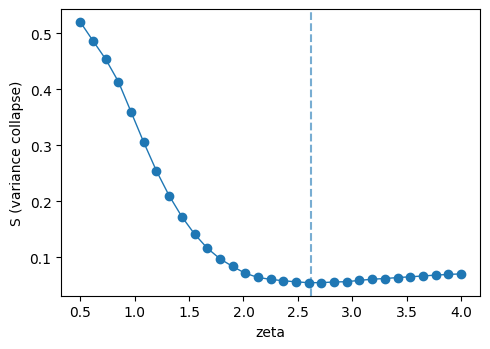

In [11]:
# -*- coding: utf-8 -*-
"""
Zeta profiling with variance only (simple & robust):
- Fix p-window to [0.75, 0.90]
- For each zeta in a grid, find best (pc, nu) on a small grid
- Choose zeta* that minimizes collapse quality S
- Refine around (pc*, nu*, zeta*) and report
"""

import numpy as np
import matplotlib.pyplot as plt
import fssa

# ---------------- Settings ----------------
npz_path = "Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz"
TEE_keys = ['TEE2','TEE3','TEE4','TEE5','TEE6']
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]

pmin, pmax = 0.75, 0.90   # ← あなたの“効く”窓を固定
nu_range   = (1.0, 3.0)
zeta_range = (0.5, 4.0)   # 物理的に >=0 を想定し、少し余裕

# 粗スキャン解像度（速くて十分良い）
rho_steps_coarse  = 41
nu_steps_coarse   = 41
zeta_steps_coarse = 31

# 局所リファイン（粗スキャンの最良付近だけ細かく見る）
rho_half_ref  = 0.01; rho_steps_ref  = 41
nu_half_ref   = 0.30; nu_steps_ref   = 41
zeta_half_ref = 0.40; zeta_steps_ref = 41

# ---------------- Utils ----------------
def eval_quality(Ls, p, A, dA, rho, nu, zeta):
    try:
        xs, ys, dys = fssa.scaledata(Ls, p, A, dA, rho, nu, zeta)
        if not (np.isfinite(xs).all() and np.isfinite(ys).all() and np.isfinite(dys).all()):
            return np.inf, None
        S = fssa.quality(xs, ys, dys)
        return (np.inf if not np.isfinite(S) else S), (xs, ys, dys)
    except Exception:
        return np.inf, None

def grid_min_fixed_zeta(Ls, p, A, dA, zeta, rho_grid, nu_grid):
    best = (np.inf, None, None, None)  # S, rho, nu, (xs,ys,dys)
    for rho0 in rho_grid:
        for nu0 in nu_grid:
            S, pack = eval_quality(Ls, p, A, dA, rho0, nu0, zeta)
            if S < best[0]:
                best = (S, rho0, nu0, pack)
    return best  # S, rho, nu, (xs,ys,dys)

def linspace_clip(center, half, steps, lo, hi):
    a = max(lo, center-half); b = min(hi, center+half)
    if a == b:
        eps = max(half, 1e-3); a = max(lo, center-eps); b = min(hi, center+eps)
    return np.linspace(a, b, steps)

# ---------------- Load & window ----------------
d = np.load(npz_path)
p_all = d['pg'].astype(float)
a_var = np.array([d[f'{k}_var'] for k in TEE_keys], dtype=float)
dA0   = np.array([d[f'{k}_err'] for k in TEE_keys], dtype=float) * 0.5

m  = (p_all >= pmin) & (p_all <= pmax)
p  = p_all[m]
A  = a_var[:, m]
dA = dA0[:,  m]

# 誤差フロア（ゼロ／過小重みを防ぐ）
dA = np.maximum(dA, 1e-6*np.maximum(1.0, np.abs(A)))

print(f"[window] p ∈ [{p.min():.6f}, {p.max():.6f}] (N={p.size})")

# ---------------- Coarse zeta profile ----------------
rho_grid_c = np.linspace(p.min(), p.max(), rho_steps_coarse)
nu_grid_c  = np.linspace(nu_range[0], nu_range[1], nu_steps_coarse)
z_grid_c   = np.linspace(zeta_range[0], zeta_range[1], zeta_steps_coarse)

S_vs_z = []
best_overall = (np.inf, None, None, None, None)  # S, rho, nu, zeta, (xs,ys,dys)

print("[coarse] scanning zeta grid...")
for j, z0 in enumerate(z_grid_c, 1):
    if j % max(1, len(z_grid_c)//10) == 0 or j == 1 or j == len(z_grid_c):
        print(f"  zeta {j}/{len(z_grid_c)}  (z0={z0:.3f})")
    Smin, rho_b, nu_b, pack = grid_min_fixed_zeta(L_list, p, A, dA, z0, rho_grid_c, nu_grid_c)
    S_vs_z.append((z0, Smin))
    if Smin < best_overall[0]:
        best_overall = (Smin, rho_b, nu_b, z0, pack)

S_coarse, rho_c, nu_c, zeta_c, pack_c = best_overall
print("\n=== coarse best ===")
print(f"zeta = {zeta_c:.6f}")
print(f"pc   = {rho_c:.6f}")
print(f"nu   = {nu_c:.6f}")
print(f"S    = {S_coarse:.6f}")

# ---------------- Refine around the coarse best ----------------
rho_grid_r = linspace_clip(rho_c,  rho_half_ref,  rho_steps_ref, p.min(), p.max())
nu_grid_r  = linspace_clip(nu_c,   nu_half_ref,   nu_steps_ref,  *nu_range)
z_grid_r   = linspace_clip(zeta_c, zeta_half_ref, zeta_steps_ref, *zeta_range)

best_ref = (np.inf, None, None, None, None)  # S, rho, nu, zeta, (xs,ys,dys)
print("\n[refine] scanning local grid around coarse best...")
for z0 in z_grid_r:
    Smin, rho_b, nu_b, pack = grid_min_fixed_zeta(L_list, p, A, dA, z0, rho_grid_r, nu_grid_r)
    if Smin < best_ref[0]:
        best_ref = (Smin, rho_b, nu_b, z0, pack)

S_star, rho_star, nu_star, zeta_star, pack_star = best_ref
print("\n=== FINAL (variance-only, profiled zeta) ===")
print(f"zeta* = {zeta_star:.6f}")
print(f"pc*   = {rho_star:.6f}")
print(f"nu*   = {nu_star:.6f}")
print(f"S*    = {S_star:.6f}")

# ---------------- (Optional) Plot S(zeta) ----------------
try:
    import matplotlib.pyplot as plt
    zs, Ss = zip(*S_vs_z)
    plt.figure(figsize=(5.0,3.6))
    plt.plot(zs, Ss, marker='o', lw=1)
    plt.axvline(zeta_star, ls='--', alpha=0.6)
    plt.xlabel("zeta"); plt.ylabel("S (variance collapse)")
    plt.tight_layout(); plt.savefig("zeta_profile_variance.png", dpi=200)
except Exception:
    pass

print("\n[Done]")



=== Variance (p∈[0.75,0.90]) ===
pc = 0.850605 ± 0.00249
nu = 1.672382 ± 0.0901
zeta = 2.547550 ± 1.01
S = 0.055714

[Done]


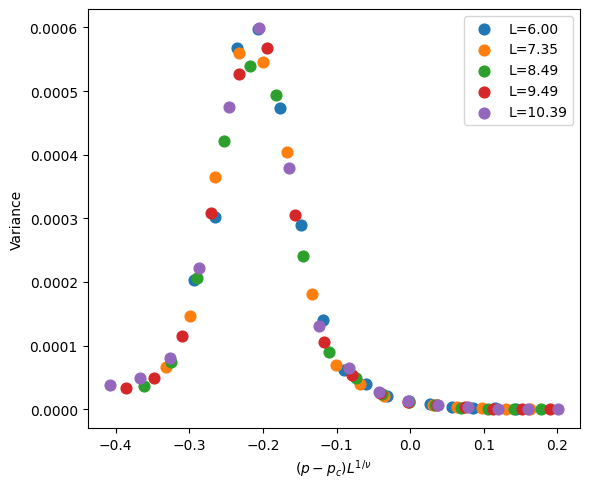

In [10]:
import numpy as np
import fssa
import matplotlib.pyplot as plt

# --- 固定設定 ---
npz_path = "Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz"
TEE_keys = ['TEE2','TEE3','TEE4','TEE5','TEE6']
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
gamma    = 0.5
pmin, pmax = 0.75, 0.90  # ←固定
seed = dict(rho_c0=0.85, nu0=1.6, zeta0=2.0)  # ←あなたが通った初期値

# --- 読み込み ---
d = np.load(npz_path)
p_all = d['pg'].astype(float)
a_var = np.array([d[f'{k}_var'] for k in TEE_keys], dtype=float)
da    = np.array([d[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

# --- p窓で切り出し ---
m = (p_all >= pmin) & (p_all <= pmax)
p = p_all[m]; A = a_var[:, m]; dA = da[:, m]
# 誤差の下限（暴走予防）
dA = np.maximum(dA, 1e-6*np.maximum(1.0, np.abs(A)))

def fit_and_report(Ls, p, A, dA, tag="var"):
    ret = fssa.autoscale(Ls, p, A, dA, **seed)
    xs, ys, dys = fssa.scaledata(Ls, p, A, dA, ret.rho, ret.nu, ret.zeta)
    S = fssa.quality(xs, ys, dys)
    print(f"\n=== {tag} ===")
    print(f"pc = {ret.rho:.6f} ± {ret.drho:.3g}")
    print(f"nu = {ret.nu:.6f} ± {ret.dnu:.3g}")
    print(f"zeta = {ret.zeta:.6f} ± {ret.dzeta:.3g}")
    print(f"S = {S:.6f}")
    return ret, xs, ys, dys, S

# 1回だけフィット
ret, xs, ys, dys, S = fit_and_report(L_list, p, A, dA, "Variance (p∈[0.75,0.90])")

# 判定と2回までのシンプル再試行
if S > 0.1:
    # (a) 一番小さいLを外す
    L2 = L_list[1:]; A2 = A[1:]; dA2 = dA[1:]
    ret, xs, ys, dys, S = fit_and_report(L2, p, A2, dA2, "Variance (drop smallest L)")
    if S > 0.1:
        # (b) 窓を少し広げる
        m2 = (p_all >= 0.74) & (p_all <= 0.90)
        p2 = p_all[m2]; A2 = a_var[:, m2]; dA2 = da[:, m2]
        dA2 = np.maximum(dA2, 1e-6*np.maximum(1.0, np.abs(A2)))
        ret, xs, ys, dys, S = fit_and_report(L_list, p2, A2, dA2, "Variance (p∈[0.74,0.90])")

# 図（任意）
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    if i < ys.shape[1]:  # Lを落とした場合のガード
        ax.scatter(xs.T[:, i], ys.T[:, i], s=60, label=f"L={L:.2f}")
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$'); ax.set_ylabel('Variance'); ax.legend()
plt.tight_layout(); plt.savefig("variance_collapse.png", dpi=300)
print("\n[Done]")


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import itertools
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# =========================================================
# 設定（ここだけ調整すればOK）
# =========================================================
npz_path   = "Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz"
TEE_keys   = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']
L_list     = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
gamma      = 0.5
save_prefix = "TEE_pz0"
cmap       = cm.get_cmap('gnuplot', 5)

# p窓 自動選択（分散ピーク ± dp）
auto_dp      = 0.07      # 収束重い/ブレる → 0.03〜0.04 に
auto_smooth  = 5         # 平滑化窓（奇数）。ノイズ大 → 7 など

# マルチスタート（まず軽量）
rho_grid     = 5         # 5→7→9 と増やす
nu_grid      = 3
zeta_grid    = 3
nu_range     = (1.0, 3.0)
zeta_range   = (1.0, 3.5)

# 追加seed（既知の良さげ値）。None は p_peak を使う意味
extra_seed_mean = (None, 1.6, 2.0)
extra_seed_var  = (None, 1.6, 2.5)

# zeta固定の安定化（必要時 True）
use_zeta_fix   = False
zeta_fix_value = 2.5

# まずは Mean のみ（軽く検証）。OKなら True にして Var も実行
DO_VAR         = True

# ジャックナイフ（頑健性チェック）
DO_JACKKNIFE   = True

# =========================================================
# ヘルパー
# =========================================================
def select_p_window_by_variance_peak(p_all, a_var, dp=0.05, smooth=5):
    """ 分散をL平均→最大点の±dpを窓にする（平滑化あり）。"""
    avg = a_var.mean(axis=0)
    if smooth and smooth > 1:
        k = int(smooth) if smooth % 2 == 1 else int(smooth) + 1
        pad = k // 2
        avg = np.convolve(np.pad(avg, (pad, pad), mode='edge'), np.ones(k)/k, mode='valid')
    i_peak = int(np.argmax(avg))
    p_peak = p_all[i_peak]
    pmin = max(p_all.min(), p_peak - dp)
    pmax = min(p_all.max(), p_peak + dp)
    mask = (p_all >= pmin) & (p_all <= pmax)
    if not np.any(mask):
        dp2 = max(1.5*dp, 0.02)
        mask = (p_all >= p_peak - dp2) & (p_all <= p_peak + dp2)
    return mask, p_peak

def autoscale_multistart(L_list, p_use, A, dA,
                         rho_range, nu_range=(1.0,3.0), zeta_range=(1.0,3.5),
                         n_rho=5, n_nu=3, n_zeta=3, seeds_extra=(), progress_every=10):
    """ 多初期値からS最小の解を採用（進捗表示付き）。"""
    best = None  # (S, ret, xs, ys, dys, seed)
    rho0s  = np.linspace(*rho_range, n_rho)
    nu0s   = np.linspace(*nu_range,  n_nu)
    zeta0s = np.linspace(*zeta_range, n_zeta)

    # seeds_extra を list 化
    seeds_extra = list(seeds_extra) if seeds_extra else []

    # 合計シード数（事前計算）
    total = n_rho * n_nu * n_zeta + len(seeds_extra)
    done  = 0

    def try_seed(r0, n0, z0):
        nonlocal best, done
        done += 1
        if progress_every and (done % progress_every == 0 or done == total):
            print(f"[progress] {done}/{total} seeds...", flush=True)
        try:
            ret = fssa.autoscale(L_list, p_use, A, dA,
                                 rho_c0=float(r0), nu0=float(n0), zeta0=float(z0))
            xs, ys, dys = fssa.scaledata(L_list, p_use, A, dA, ret.rho, ret.nu, ret.zeta)
            S = fssa.quality(xs, ys, dys)  # 小さいほど良い
            if (best is None) or (S < best[0]):
                best = (S, ret, xs, ys, dys, (float(r0), float(n0), float(z0)))
        except Exception:
            pass

    # グリッド走査
    for r0, n0, z0 in itertools.product(rho0s, nu0s, zeta0s):
        try_seed(r0, n0, z0)
    # 追加seed
    for r0, n0, z0 in seeds_extra:
        try_seed(r0, n0, z0)

    if best is None:
        raise RuntimeError("autoscale が全初期値で失敗。p窓・誤差・データを見直してください。")
    return best

def jackknife_quality_over_p_and_L(L_list, p_use, A, dA, ret_params):
    """ p点/Lサイズを1つずつ落として S を再計算。"""
    rho, nu, zeta = ret_params
    xs, ys, dys = fssa.scaledata(L_list, p_use, A, dA, rho, nu, zeta)
    base_S = fssa.quality(xs, ys, dys)

    # p-LOO
    S_p = []
    for j in range(p_use.size):
        mask = np.ones(p_use.size, dtype=bool); mask[j] = False
        xsj, ysj, dysj = fssa.scaledata(L_list, p_use[mask], A[:,mask], dA[:,mask], rho, nu, zeta)
        S_p.append(fssa.quality(xsj, ysj, dysj))
    S_p = np.array(S_p)

    # L-LOO
    S_L = []
    L_arr = np.array(L_list, dtype=float)
    for i in range(len(L_list)):
        keep = np.ones(len(L_list), dtype=bool); keep[i] = False
        xsL, ysL, dysL = fssa.scaledata(L_arr[keep], p_use, A[keep,:], dA[keep,:], rho, nu, zeta)
        S_L.append(fssa.quality(xsL, ysL, dysL))
    S_L = np.array(S_L)
    return base_S, S_p, S_L

def all_finite_report(name, arr):
    ok = np.isfinite(arr).all()
    print(f"[check] {name:12s} shape={arr.shape} finite={ok}")
    if not ok:
        bad = np.argwhere(~np.isfinite(arr))
        print(f"  bad indices (first 10): {bad[:10]}")
    return ok

# =========================================================
# データ読み込み
# =========================================================
data = np.load(npz_path)
p_all = data['pg']  # shape=(nP,)
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 分散に別誤差があれば差し替え

# =========================================================
# p窓の自動選択（分散ピーク±dp）
# =========================================================
mask_auto, p_peak = select_p_window_by_variance_peak(p_all, a_var, dp=auto_dp, smooth=auto_smooth)
p_use = p_all[mask_auto]
a_mean_sel  = a_mean[:,  mask_auto]
da_mean_sel = da_mean[:, mask_auto]
a_var_sel   = a_var[:,   mask_auto]
da_var_sel  = da_var[:,  mask_auto]

print(f"[auto-window] p_peak ≈ {p_peak:.6f}, window = [{p_use.min():.6f}, {p_use.max():.6f}], Np = {p_use.size}")

# =========================================================
# Sanity check（NaN/Inf/形状）
# =========================================================
ok = True
ok &= all_finite_report("p_use",       p_use)
ok &= all_finite_report("a_mean_sel",  a_mean_sel)
ok &= all_finite_report("da_mean_sel", da_mean_sel)
ok &= all_finite_report("a_var_sel",   a_var_sel)
ok &= all_finite_report("da_var_sel",  da_var_sel)
if not ok:
    raise ValueError("非有限値が含まれています。データを確認してください。")

# =========================================================
# 誤差の下限（極小誤差点の暴走防止）
# =========================================================
eps_m = 1e-6 * np.maximum(1.0, np.abs(a_mean_sel))
eps_v = 1e-6 * np.maximum(1.0, np.abs(a_var_sel))
da_mean_sel = np.maximum(da_mean_sel, eps_m)
da_var_sel  = np.maximum(da_var_sel,  eps_v)

# =========================================================
# smoke test（1回だけ試走：返ってくるか確認）
# =========================================================
print("[smoke] trying autoscale (mean) at peak seed...")
ret_smoke = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                           rho_c0=float(p_peak), nu0=1.6, zeta0=2.0)
print("[smoke] ok: pc=%.6f, nu=%.4f, zeta=%.4f" % (ret_smoke.rho, ret_smoke.nu, ret_smoke.zeta))

# =========================================================
# マルチスタート最適化：平均
# =========================================================
rho_range = (p_use.min(), p_use.max())
seed_mean = [(p_peak if extra_seed_mean[0] is None else extra_seed_mean[0],
              extra_seed_mean[1], extra_seed_mean[2])]

# 必要なら zeta 固定→その解を 3パラの種に
if use_zeta_fix:
    print("[zeta-fix] running temporary fit with fixed zeta=%.3f" % zeta_fix_value)
    ret_tmp = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                             rho_c0=p_peak, nu0=(nu_range[0]+nu_range[1])/2, zeta0=zeta_fix_value)
    seed_mean.append((ret_tmp.rho, ret_tmp.nu, ret_tmp.zeta))

print("[mean] multistart begin...")
best_mean = autoscale_multistart(
    L_list, p_use, a_mean_sel, da_mean_sel,
    rho_range=rho_range, nu_range=nu_range, zeta_range=zeta_range,
    n_rho=rho_grid, n_nu=nu_grid, n_zeta=zeta_grid,
    seeds_extra=seed_mean, progress_every=10
)
S_mean, ret_mean, xs_mean, ys_mean, dys_mean, used_seed_mean = best_mean

print("\n=== 平均 FSS (multi-start) ===")
print(f"pc   = {ret_mean.rho:.6f} ± {ret_mean.drho:.3g}")
print(f"nu   = {ret_mean.nu:.6f} ± {ret_mean.dnu:.3g}")
print(f"zeta = {ret_mean.zeta:.6f} ± {ret_mean.dzeta:.3g}")
print(f"S    = {S_mean:.4g}  (seed={used_seed_mean})")

# =========================================================
# プロット（平均）
# =========================================================
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i], s=80, label=f'{key}, L={L:.2f}')
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)
plt.tight_layout()
plt.savefig(f"{save_prefix}_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# =========================================================
# マルチスタート最適化：分散（任意）
# =========================================================
if DO_VAR:
    print("[var ] multistart begin...")
    seed_var = [(p_peak if extra_seed_var[0] is None else extra_seed_var[0],
                 extra_seed_var[1], extra_seed_var[2])]

    best_var = autoscale_multistart(
        L_list, p_use, a_var_sel, da_var_sel,
        rho_range=rho_range, nu_range=nu_range, zeta_range=zeta_range,
        n_rho=rho_grid, n_nu=nu_grid, n_zeta=zeta_grid,
        seeds_extra=seed_var, progress_every=10
    )
    S_var, ret_var, xs_var, ys_var, dys_var, used_seed_var = best_var

    print("\n=== 分散 FSS (multi-start) ===")
    print(f"pc   = {ret_var.rho:.6f} ± {ret_var.drho:.3g}")
    print(f"nu   = {ret_var.nu:.6f} ± {ret_var.dnu:.3g}")
    print(f"zeta = {ret_var.zeta:.6f} ± {ret_var.dzeta:.3g}")
    print(f"S    = {S_var:.4g}  (seed={used_seed_var})")

    # プロット（分散）
    fig, ax = plt.subplots(figsize=(6,5))
    for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
        ax.scatter(xs_var.T[:, i], ys_var.T[:, i], s=80, label=f'{key}, L={L:.2f}')
    ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
    ax.set_ylabel('Variance', fontsize=14)
    ax.legend()
    plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_variance.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# =========================================================
# ジャックナイフ（任意）
# =========================================================
if DO_JACKKNIFE:
    baseS_m, S_p_m, S_L_m = jackknife_quality_over_p_and_L(
        L_list, p_use, a_mean_sel, da_mean_sel, (ret_mean.rho, ret_mean.nu, ret_mean.zeta)
    )
    print("\n=== ジャックナイフ（Mean）===")
    IQRm = np.percentile(S_p_m, 75) - np.percentile(S_p_m, 25)
    IQRl = np.percentile(S_L_m, 75) - np.percentile(S_L_m, 25)
    print(f"base S = {baseS_m:.4g}")
    print(f"p-LOO: median={np.median(S_p_m):.4g}, IQR={IQRm:.4g}, min={S_p_m.min():.4g}, max={S_p_m.max():.4g}")
    print(f"L-LOO: median={np.median(S_L_m):.4g}, IQR={IQRl:.4g}, min={S_L_m.min():.4g}, max={S_L_m.max():.4g}")

    if DO_VAR:
        baseS_v, S_p_v, S_L_v = jackknife_quality_over_p_and_L(
            L_list, p_use, a_var_sel, da_var_sel, (ret_var.rho, ret_var.nu, ret_var.zeta)
        )
        print("\n=== ジャックナイフ（Variance）===")
        IQRm = np.percentile(S_p_v, 75) - np.percentile(S_p_v, 25)
        IQRl = np.percentile(S_L_v, 75) - np.percentile(S_L_v, 25)
        print(f"base S = {baseS_v:.4g}")
        print(f"p-LOO: median={np.median(S_p_v):.4g}, IQR={IQRm:.4g}, min={S_p_v.min():.4g}, max={S_p_v.max():.4g}")
        print(f"L-LOO: median={np.median(S_L_v):.4g}, IQR={IQRl:.4g}, min={S_L_v.min():.4g}, max={S_L_v.max():.4g}")

print("\n[Done]")


In [9]:
# -*- coding: utf-8 -*-
"""
FSSA with robust handling for MEAN background:
- Fixed p-window: [0.75, 0.90]
- VAR: autoscale (your working seed) -> small local refinement grid
- MEAN: try three transforms on mean data:
    A) raw
    B) per-L centering at p ≈ pc (subtract constant offset)
    C) per-L linear detrending over window (remove slope+intercept)
  Do small-band grid search around variance solution for each, pick the best S.
- Error floors: absolute + relative (avoid overweight points)
- Plots + summary
"""

import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
from itertools import product

# ====================== Settings ======================
npz_path   = "Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz"
TEE_keys   = ['TEE2','TEE3','TEE4','TEE5','TEE6']
L_list     = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
gamma      = 0.5
save_prefix = "TEE_mean_bgfix"

# 固定 p 窓（あなたの “うまくいった” 条件）
pmin_manual = 0.75
pmax_manual = 0.90

# 分散の初期シード（あなたが通せたやつ）
seed_var_init = dict(rho_c0=0.85, nu0=1.6, zeta0=2.0)

# 分散の局所グリッド（微調整帯域）
d_rho_v, d_nu_v, d_ze_v = 0.01, 0.30, 0.70
n_rho_v, n_nu_v, n_ze_v = 7,  7,   7
nu_bounds   = (1.0, 3.0)
zeta_bounds = (0.5, 4.0)  # 0.5以上で暴走抑止

# 平均の小帯域グリッド（分散の最良点近傍）
d_rho_m, d_nu_m, d_ze_m = 0.02, 0.40, 0.80
n_rho_m, n_nu_m, n_ze_m = 41,   21,   31

# 誤差の下限（平均で S 爆発を防ぐ）：abs + rel*|y|
MEAN_ERR_ABS = 1e-3
MEAN_ERR_REL = 0.02   # 2% 程度（データに応じて 1–5% を調整）

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ====================== Utils ======================
def check_finite(name, arr):
    ok = np.isfinite(arr).all()
    print(f"[check] {name:12s} shape={arr.shape} finite={ok}")
    if not ok:
        bad = np.argwhere(~np.isfinite(arr))
        print(f"  bad indices (first 10): {bad[:10]}")
    return ok

def ensure_sorted_unique_p(p, arrays_on_p):
    p = np.asarray(p).ravel()
    idx = np.argsort(p)
    p_sorted = p[idx]
    arrays_sorted = [A[:, idx] for A in arrays_on_p]
    uniq, inv, cnt = np.unique(p_sorted, return_inverse=True, return_counts=True)
    if uniq.size != p_sorted.size:
        print(f"[warn] duplicate p detected. collapsing {p_sorted.size - uniq.size} duplicates by averaging.")
        new_arrays = []
        for A in arrays_sorted:
            out = np.zeros((A.shape[0], uniq.size), dtype=A.dtype)
            for g in range(uniq.size):
                cols = (inv == g)
                out[:, g] = A[:, cols].mean(axis=1)
            new_arrays.append(out)
        return uniq, new_arrays
    return p_sorted, arrays_sorted

def eval_quality(L_list, p_use, A, dA, rho, nu, zeta):
    try:
        xs, ys, dys = fssa.scaledata(L_list, p_use, A, dA, rho, nu, zeta)
        if not (np.isfinite(xs).all() and np.isfinite(ys).all() and np.isfinite(dys).all()):
            return np.inf, None, None, None
        S = fssa.quality(xs, ys, dys)
        return (np.inf if not np.isfinite(S) else S), xs, ys, dys
    except Exception:
        return np.inf, None, None, None

def linspace_clip(center, half, steps, lo, hi):
    a = max(lo, center - half)
    b = min(hi, center + half)
    if a == b:
        eps = max(half, 1e-3)
        a = max(lo, center - eps); b = min(hi, center + eps)
    return np.linspace(a, b, steps)

def perL_centering(A, p_use, pc):
    """各Lについて、pcに最も近いpの値を基準に定数項を差し引く"""
    idx_ref = int(np.argmin(np.abs(p_use - pc)))
    return A - A[:, [idx_ref]]

def perL_linear_detrend(A, p_use):
    """各Lについて、y ~ a + b p を最小二乗で当てて、(y - (a + b p)) を返す"""
    P = np.vstack([np.ones_like(p_use), p_use]).T  # [1, p]
    out = np.empty_like(A)
    for i in range(A.shape[0]):
        # 最小二乗
        try:
            coef, *_ = np.linalg.lstsq(P, A[i].T, rcond=None)
            trend = (coef[0] + coef[1]*p_use)
            out[i] = A[i] - trend
        except Exception:
            out[i] = A[i] - np.mean(A[i])
    return out

# ====================== Load ======================
data = np.load(npz_path)
p_all = data['pg'].astype(float)  # (nP,)
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)  # (nL,nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

print("[info] loaded:", npz_path)
print(f"[info] TEE_keys={TEE_keys}")
print(f"[info] L_list={L_list}")

ok = True
ok &= check_finite("p_all", p_all)
ok &= check_finite("a_mean", a_mean)
ok &= check_finite("da_mean", da_mean)
ok &= check_finite("a_var",  a_var)
ok &= check_finite("da_var", da_var)
if not ok:
    raise SystemExit("Non-finite values detected.")

# p を昇順・重複は平均で潰す
p_all, [a_mean, da_mean, a_var, da_var] = ensure_sorted_unique_p(p_all, [a_mean, da_mean, a_var, da_var])

# ====================== Manual p-window ======================
mask = (p_all >= pmin_manual) & (p_all <= pmax_manual)
if mask.sum() < 6:
    raise SystemExit(f"[fatal] too few points in manual window [{pmin_manual},{pmax_manual}]")
p_use = p_all[mask]
a_mean_w, da_mean_w = a_mean[:, mask], da_mean[:, mask]
a_var_w,  da_var_w  = a_var[:,  mask], da_var[:,  mask]
print(f"\n[window] Using manual p-range [{p_use.min():.6f}, {p_use.max():.6f}] (Np={p_use.size})")

# 誤差フロア（平均は相対項も追加）
eps_v = 1e-6 * np.maximum(1.0, np.abs(a_var_w))
da_var_w  = np.maximum(da_var_w,  eps_v)

abs_floor = MEAN_ERR_ABS
rel_floor = MEAN_ERR_REL
da_mean_w = np.maximum(da_mean_w, abs_floor + rel_floor*np.abs(a_mean_w))

# ====================== Variance: autoscale anchor ======================
print("\n[variance] autoscale with your working seed…")
ret_v0 = fssa.autoscale(L_list, p_use, a_var_w, da_var_w, **seed_var_init)
S_v0, xs_v0, ys_v0, dys_v0 = eval_quality(L_list, p_use, a_var_w, da_var_w, ret_v0.rho, ret_v0.nu, ret_v0.zeta)
print("=== Variance (anchor) ===")
print(f"pc   = {ret_v0.rho:.6f} ± {ret_v0.drho:.3g}")
print(f"nu   = {ret_v0.nu:.6f} ± {ret_v0.dnu:.3g}")
print(f"zeta = {ret_v0.zeta:.6f} ± {ret_v0.dzeta:.3g}")
print(f"S    = {S_v0:.6f}")

# ====================== Variance: local refinement grid ======================
print("\n[variance] small local grid refinement…")
def lin_clip(center, half, n, lo, hi):
    return linspace_clip(center, half, n, lo, hi)

rho_grid = lin_clip(ret_v0.rho, d_rho_v, n_rho_v, p_use.min(), p_use.max())
nu_grid  = lin_clip(ret_v0.nu,  d_nu_v,  n_nu_v,  *nu_bounds)
ze_grid  = lin_clip(ret_v0.zeta,d_ze_v,  n_ze_v,  *zeta_bounds)

best_v = (np.inf, None, None, None, (None,None,None))
total  = len(rho_grid)*len(nu_grid)*len(ze_grid)
done   = 0
for r0, n0, z0 in product(rho_grid, nu_grid, ze_grid):
    done += 1
    if done % max(1, total//10) == 0 or done == total or done == 1:
        print(f"  progress {done}/{total}…", flush=True)
    S, xs, ys, dys = eval_quality(L_list, p_use, a_var_w, da_var_w, r0, n0, z0)
    if S < best_v[0]:
        best_v = (S, xs, ys, dys, (r0, n0, z0))
S_v, xs_v, ys_v, dys_v, (rho_v, nu_v, ze_v) = best_v

print("=== Variance (refined) ===")
print(f"pc   = {rho_v:.6f}")
print(f"nu   = {nu_v:.6f}")
print(f"zeta = {ze_v:.6f}")
print(f"S    = {S_v:.6f}")

# ====================== Mean: try three transforms ======================
def mean_attempt(label, A_mean_in, dA_in, rho_c, nu_c, ze_c):
    # 小帯域グリッド（分散最良点のまわり）
    rho_grid_m = lin_clip(rho_c, d_rho_m, n_rho_m, p_use.min(), p_use.max())
    nu_grid_m  = lin_clip(nu_c,  d_nu_m,  n_nu_m,  *nu_bounds)
    ze_grid_m  = lin_clip(max(0.5, ze_c), d_ze_m,  n_ze_m,  *zeta_bounds)  # ζ>=0.5
    best = (np.inf, None, None, None, (None,None,None))
    total = len(rho_grid_m)*len(nu_grid_m)*len(ze_grid_m)
    done=0
    print(f"\n[mean-{label}] grid search …")
    for r0, n0, z0 in product(rho_grid_m, nu_grid_m, ze_grid_m):
        done += 1
        if done % max(1, total//10) == 0 or done == total or done == 1:
            print(f"  progress {done}/{total}…", flush=True)
        S, xs, ys, dys = eval_quality(L_list, p_use, A_mean_in, dA_in, r0, n0, z0)
        if S < best[0]:
            best = (S, xs, ys, dys, (r0, n0, z0))
    return best

# (A) raw
best_A = mean_attempt("raw", a_mean_w, da_mean_w, rho_v, nu_v, ze_v)

# (B) per-L centering at pc≈rho_v
a_mean_center = perL_centering(a_mean_w.copy(), p_use, rho_v)
da_mean_center = da_mean_w.copy()  # 誤差は同じ扱い
best_B = mean_attempt("center", a_mean_center, da_mean_center, rho_v, nu_v, ze_v)

# (C) per-L linear detrend
a_mean_detr = perL_linear_detrend(a_mean_w.copy(), p_use)
da_mean_detr = da_mean_w.copy()
best_C = mean_attempt("detrend", a_mean_detr, da_mean_detr, rho_v, nu_v, ze_v)

# 3候補から最良を採用
candidates = {"raw": best_A, "center": best_B, "detrend": best_C}
best_label, (S_m, xs_m, ys_m, dys_m, (rho_m, nu_m, ze_m)) = min(
    candidates.items(), key=lambda kv: kv[1][0]
)
print(f"\n[mean] best transform = {best_label}")

# ====================== Plots ======================
cmap = cm.get_cmap('gnuplot', len(L_list))

# Variance collapse
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_v.T[:, i], ys_v.T[:, i], s=80, label=f'{key}, L={L:.2f}')
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse  (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=15)
plt.tight_layout()
plt.savefig(f"{save_prefix}_variance.png", dpi=300, bbox_inches='tight')
plt.close(fig)

# Mean collapse (best)
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_m.T[:, i], ys_m.T[:, i], s=80, label=f'{key}, L={L:.2f}')
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean (bg-fixed)', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse [{best_label}]  (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=15)
plt.tight_layout()
plt.savefig(f"{save_prefix}_mean_{best_label}.png", dpi=300, bbox_inches='tight')
plt.close(fig)

# ====================== Summary ======================
print("\n===== SUMMARY (manual window pinned) =====")
print(f"Window: p∈[{p_use.min():.6f}, {p_use.max():.6f}] (Np={p_use.size})")
print("[Variance]")
print(f"  pc   = {rho_v:.6f}")
print(f"  nu   = {nu_v:.6f}")
print(f"  zeta = {ze_v:.6f}")
print(f"  S    = {S_v:.6f}")
print(f"[Mean | best={best_label}]")
print(f"  pc   = {rho_m:.6f}")
print(f"  nu   = {nu_m:.6f}")
print(f"  zeta = {ze_m:.6f}")
print(f"  S    = {S_m:.6f}")
print("[Done]")


[info] loaded: Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz
[info] TEE_keys=['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']
[info] L_list=[6.0, 7.3484692283495345, 8.48528137423857, 9.486832980505138, 10.392304845413264]
[check] p_all        shape=(21,) finite=True
[check] a_mean       shape=(5, 21) finite=True
[check] da_mean      shape=(5, 21) finite=True
[check] a_var        shape=(5, 21) finite=True
[check] da_var       shape=(5, 21) finite=True

[window] Using manual p-range [0.750000, 0.900000] (Np=16)

[variance] autoscale with your working seed…
=== Variance (anchor) ===
pc   = 0.850605 ± 0.00249
nu   = 1.672382 ± 0.0901
zeta = 2.547550 ± 1.01
S    = 0.055714

[variance] small local grid refinement…
  progress 1/343…
  progress 34/343…
  progress 68/343…
  progress 102/343…
  progress 136/343…
  progress 170/343…
  progress 204/343…
  progress 238/343…
  progress 272/343…
  progress 306/343…
  progress 340/343…
  progress 343/343…
=== Variance (refined) ===
pc   = 0.853938
nu   = 1